In [ ]:
import requests
import pandas as pd
import time
import json
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from google.colab import drive

In [ ]:
API_KEY = "ocultado"
NUM_WORKERS = 12
MODEL_NAME = "openai/gpt-4.1-mini"
RETRIES = 3
TIMEOUT = 40
SAMPLE_SIZE = 6000
CHECKPOINT_EVERY = 500

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Linguamática"
CAMINHO_ARQUIVO = f"{BASE_DIR}/frases-musicas-final-filled.csv"
ARQ_SAIDA_FINAL = f"{BASE_DIR}/anotacao_llm_6k.csv"
ARQ_LOG = f"{BASE_DIR}/log_anotacao_llm.txt"
ARQ_ERRORS = f"{BASE_DIR}/errors_llm.jsonl"

In [ ]:
logging.basicConfig(
    filename=ARQ_LOG,
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)

print("Logging em:", ARQ_LOG)

Logging em: /content/drive/MyDrive/Linguamática/log_anotacao_llm.txt


In [ ]:
def parse_answer(raw_answer: str) -> str:
    """
    Tenta extrair SIM ou NÃO de uma resposta de LLM de forma robusta.
    """
    if not isinstance(raw_answer, str):
        return "ERRO"

    raw = raw_answer.strip().upper()

    # limpar pontuação básica
    clean = (
        raw.replace(".", "")
           .replace("!", "")
           .replace("?", "")
           .replace(":", "")
           .replace(";", "")
           .strip()
    )

    # casos perfeitos
    if clean == "SIM":
        return "SIM"
    if clean == "NÃO" or clean == "NAO":
        return "NÃO"

    # começa com SIM/NÃO
    if clean.startswith("SIM"):
        return "SIM"
    if clean.startswith("NÃO") or clean.startswith("NAO"):
        return "NÃO"

    # contém SIM/NÃO em alguma parte
    if " SIM" in clean or clean.endswith("SIM"):
        return "SIM"
    if " NÃO" in clean or " NAO" in clean or clean.endswith("NÃO") or clean.endswith("NAO"):
        return "NÃO"

    # fallback: ainda tentar pelas palavras
    if "SIM" in clean:
        return "SIM"
    if "NÃO" in clean or "NAO" in clean:
        return "NÃO"

    return "ERRO"


def llm_judge(frase: str) -> str:
    """
    Chama a LLM via OpenRouter para classificar uma frase como SIM ou NÃO.
    Retorna: "SIM", "NÃO" ou "ERRO".
    """
    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    prompt = f"""
Você é um anotador especializado em linguística. Seu objetivo é identificar se uma frase contém OU NÃO uma caracterização de pessoa.

Caracterização significa atribuir um atributo, qualidade, estado, condição, sentimento ou propriedade a uma pessoa (explícita ou implícita). A classificação é binária.

SIM = a frase contém caracterização ou qualificação de uma pessoa (atributo, qualidade, estado, condição, emoção, identidade, comportamento).
NÃO = a frase NÃO contém caracterização de uma pessoa.

# Exemplos reais de música brasileira:

Frase: "Ela é bonita, seus olhos são como o mar."
Resposta: SIM

Frase: "Ele é um bom sujeito."
Resposta: SIM

Frase: "Meu coração não se cansa."
Resposta: NÃO   # não descreve pessoa, descreve o coração

Frase: "Você é luz, é raio de sol."
Resposta: SIM   # metáfora, mas é caracterização

Frase: "Ela só quer, só pensa em namorar."
Resposta: SIM   # descreve comportamento/estado

Frase: "Danço eu, dança você."
Resposta: NÃO   # ação, sem atributo/qualidade

Frase: "Meu mundo é hoje."
Resposta: NÃO   # sem pessoa caracterizada

Frase: "Ele era só um rapaz latino-americano."
Resposta: SIM   # 'latino-americano' é caracterização identitária

Frase: "Eu só sei que te amo demais."
Resposta: NÃO   # fala sobre sentimento, não caracteriza o outro

Frase: "Ela tem brilho próprio."
Resposta: SIM   # caracterização metafórica

Regras:
- Responda APENAS com SIM ou NÃO
- Não escreva explicações.
- Não escreva frases.
- Não reescreva a frase.
- Não adicione pontuação extra.

Frase: "{frase}"

Resposta:
""".strip()

    data = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }

    last_error = None

    for attempt in range(1, RETRIES + 1):
        try:
            response = requests.post(url, headers=headers, json=data, timeout=TIMEOUT)

            # status de erro da API
            if response.status_code != 200:
                last_error = f"status_code={response.status_code}, body={response.text[:500]}"
                logging.warning(f"HTTP error na chamada da LLM: {last_error}")
                time.sleep(1.5 * attempt)
                continue

            try:
                result = response.json()
            except Exception as e_json:
                last_error = f"JSONDecodeError: {str(e_json)} body={response.text[:500]}"
                logging.warning(last_error)
                time.sleep(1.5 * attempt)
                continue

            if "choices" not in result or not result["choices"]:
                last_error = f"Resposta sem 'choices': {json.dumps(result)[:500]}"
                logging.warning(last_error)
                time.sleep(1.5 * attempt)
                continue

            answer = result["choices"][0]["message"]["content"]
            parsed = parse_answer(answer)

            if parsed == "ERRO":
                logging.warning(f"Resposta inesperada da LLM. raw_answer={repr(answer)[:300]}")
                return "ERRO"

            return parsed

        except Exception as e:
            last_error = str(e)
            logging.warning(f"Exceção na chamada da LLM: {last_error}")
            time.sleep(1.5 * attempt)

    # se chegou aqui, falhou em todas as tentativas
    try:
        with open(ARQ_ERRORS, "a", encoding="utf-8") as f:
            f.write(json.dumps({
                "frase": frase,
                "erro": last_error,
            }, ensure_ascii=False) + "\n")
    except Exception as e_file:
        logging.error(f"Falha ao escrever em {ARQ_ERRORS}: {e_file}")

    return "ERRO"

In [ ]:
drive.mount('/content/drive')

df = pd.read_csv(CAMINHO_ARQUIVO)

df_n = df[df["tem_padrao"] == "N"].copy()

if len(df_n) < SAMPLE_SIZE:
    print(f"Atenção: tem apenas {len(df_n)} linhas com tem_padrao == 'N'. Usando todas.")
    df_sample = df_n[["frase_id", "frase"]].copy()
else:
    df_sample = df_n[["frase_id", "frase"]].sample(n=SAMPLE_SIZE, random_state=42)

df_sample = df_sample.reset_index(drop=True)
print("Tamanho da amostra:", len(df_sample))

Mounted at /content/drive
Tamanho da amostra: 6000


In [ ]:
def process_row(idx_row_tuple):
    """
    Função executada em paralelo.
    Recebe (idx, row) porque vamos usar o índice para controle.
    """
    idx, row = idx_row_tuple
    frase_id = row["frase_id"]
    frase = row["frase"]

    start = time.time()
    anotacao = llm_judge(frase)
    end = time.time()

    logging.info(
        f"frase_id={frase_id} anotacao={anotacao} tempo_resposta={end-start:.2f}s"
    )

    return idx, frase_id, frase, anotacao


results = []

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = [
        executor.submit(process_row, item)
        for item in df_sample.iterrows()
    ]

    for future in tqdm(as_completed(futures), total=len(futures)):
        idx, frase_id, frase, anotacao = future.result()
        results.append((idx, frase_id, frase, anotacao))

        # checkpoint periódico
        if len(results) % CHECKPOINT_EVERY == 0:
            df_checkpoint = pd.DataFrame(
                results,
                columns=["idx", "frase_id", "frase", "llm_anotacao"]
            ).sort_values("idx")
            df_checkpoint.to_csv(
                f"{BASE_DIR}/anotacao_llm_checkpoint_{len(results)}.csv",
                index=False
            )
            logging.info(f"Checkpoint salvo com {len(results)} linhas.")

100%|██████████| 6000/6000 [35:49<00:00,  2.79it/s]


In [ ]:
df_parallel = pd.DataFrame(
    results,
    columns=["idx", "frase_id", "frase", "llm_anotacao"]
).sort_values("idx")

# descartar idx auxiliar
df_parallel = df_parallel[["frase_id", "frase", "llm_anotacao"]]

df_parallel.to_csv(ARQ_SAIDA_FINAL, index=False)

print("Arquivo final salvo em:", ARQ_SAIDA_FINAL)
print("Distribuição das anotações:")
print(df_parallel["llm_anotacao"].value_counts(dropna=False))

Arquivo final salvo em: /content/drive/MyDrive/Linguamática/anotacao_llm_6k.csv
Distribuição das anotações:
llm_anotacao
NÃO    5010
SIM     990
Name: count, dtype: int64


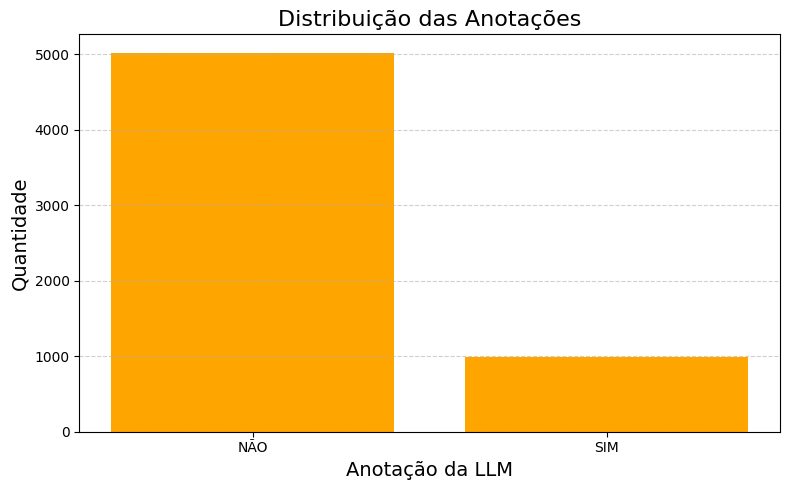

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

counts = df_parallel["llm_anotacao"].value_counts(dropna=False)

plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values, color="orange")
plt.title("Distribuição das Anotações", fontsize=16)
plt.xlabel("Anotação da LLM", fontsize=14)
plt.ylabel("Quantidade", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
